In [17]:
# Importing the necessary libararies
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

In [14]:
Modelling_Data = pd.read_csv(r'C:/Users/User/Downloads/Fraudulent-Transaction_Detection_For_FinLora_Company/Notebooks/Modelling.ipynb')

ParserError: Error tokenizing data. C error: Expected 1 fields in line 4, saw 2


In [ ]:
Modelling_Data = pd.read_csv(r'..\Finlora_Dataset\artifacts\EDA_Data.csv')

In [ ]:
Modelling_Data.head()

,Unnamed: 0,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,...,corridor_risk,is_fraud,hour,day_of_week,is_weekend,month,account_age_bucket,device_trust_score_bucket,ip_risk_score_bucket,amount_usd_bucket
0,0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,us,USD,CAD,atm,278.19,278.19,...,0.0,0,18,0,0,10,180-365,0.5-0.7,<0.2,$250-500
1,1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,ca,CAD,MXN,web,208.51,154.29,...,0.0,0,20,0,0,10,>365,0.3-0.5,0.4-0.6,<$250
2,2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,us,USD,CNY,mobile,160.33,160.33,...,0.0,0,23,0,0,10,>365,>0.9,0.4-0.6,<$250
3,3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,us,USD,EUR,mobile,59.41,59.41,...,0.0,0,1,1,0,10,90-180,0.5-0.7,0.4-0.6,<$250
4,4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,us,USD,INR,mobile,200.96,200.96,...,0.0,0,9,1,0,10,180-365,0.7-0.9,<0.2,<$250


In [ ]:
Modelling_Data['timestamp'] = pd.to_datetime(Modelling_Data['timestamp'])

categorical_features = Modelling_Data.select_dtypes(include=['object', 'bool']).columns
categorical_features


Index(['transaction_id', 'customer_id', 'home_country', 'source_currency',
       'dest_currency', 'channel', 'device_id', 'new_device', 'ip_address',
       'ip_country', 'location_mismatch', 'kyc_tier', 'account_age_bucket',
       'device_trust_score_bucket', 'ip_risk_score_bucket',
       'amount_usd_bucket'],
      dtype='object')

In [ ]:
# Defining numerical features
numerical_features = Modelling_Data.select_dtypes(include=['int', 'float']).columns.drop('is_fraud')
numerical_features

Index(['Unnamed: 0', 'amount_src', 'amount_usd', 'fee',
       'exchange_rate_src_to_dest', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour',
       'day_of_week', 'is_weekend', 'month'],
      dtype='object')

In [ ]:
all_features = list(categorical_features) + list(numerical_features)
print(all_features)

['transaction_id', 'customer_id', 'home_country', 'source_currency', 'dest_currency', 'channel', 'device_id', 'new_device', 'ip_address', 'ip_country', 'location_mismatch', 'kyc_tier', 'account_age_bucket', 'device_trust_score_bucket', 'ip_risk_score_bucket', 'amount_usd_bucket', 'Unnamed: 0', 'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week', 'is_weekend', 'month']


Train_test Split

The data is split into: 80% of data used to train the model and 20% is reserved to test its performance on unseen data.

It is strongly recommended to sort the dataset chronologically before doing the train-test split. Since your dataset has a timestamp column, the order of events matters. This will prevent data leakage, help predict future transactions since model will trained on past transactions hence mimicking the real scenario.

Features like: txn_velocity_1h, txn_velocity_24h, new_device, account_age_days, new_account depend on historical order. If data is not ordered by time, these features can become incorrect.

In [ ]:
# sorting by timestamp
Modelling_Data = Modelling_Data.sort_values(by='timestamp')

# 80/20 train_test split
split_index = int(len(Modelling_Data) * 0.8)  # This determines where the dataset should be split.
train_Modelling_Data = Modelling_Data.iloc[:split_index]  # training on future transactions
test_Modelling_Data = Modelling_Data.iloc[split_index:]  # testing on past transactions

# prepare X and y
X_train = train_Modelling_Data[all_features]
y_train = train_Modelling_Data['is_fraud']
X_test = test_Modelling_Data[all_features]
y_test = test_Modelling_Data['is_fraud']

In [ ]:
print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


X_train: (8624, 33), y_train: (8624,)
X_test: (2156, 33), y_test: (2156,)


Training Logistic Regression with a balanced class weight

In [15]:
# Create Logistic Regression model
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Build the complete pipeline
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', lr_model)
    ]
)

# Train the pipeline
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['transaction_id','customer_id','home_country',...,'day_of_week', 'is_weekend','month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [18]:
# Train the pipeline
pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lr = pipeline.predict(X_test)
y_proba_lr = pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

c:\Users\User\Downloads\Fraudulent-Transaction_Detection_For_FinLora_Company\finLora_env\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 6, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\User\Downloads\Fraudulent-Transaction_Detection_For_FinLora_Company\finLora_env\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 6, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Logistic Regression Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      1848
       Fraud       0.96      0.93      0.94       308

    accuracy                           0.98      2156
   macro avg       0.97      0.96      0.97      2156
weighted avg       0.98      0.98      0.98      2156


Confusion Matrix:
[[1835   13]
 [  22  286]]

ROC_AUC Score: 0.9819


Confusion Matrix For Linear Regression

<Figure size 800x600 with 0 Axes>

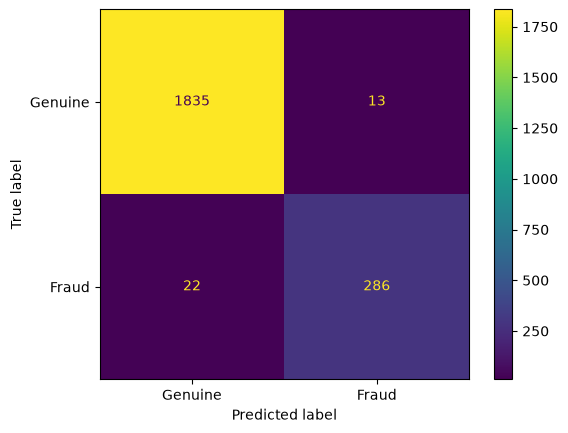

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6))
cm.plot()

Training Random forest with balanced class weight  

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    max_depth=10,
    n_jobs=-1
)

# Build the complete pipeline
pipeline_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', rf_model)
    ]
)

# Train the pipeline (using raw X_train, not processed)
pipeline_rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

c:\Users\User\Downloads\Fraudulent-Transaction_Detection_For_FinLora_Company\finLora_env\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 6, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\User\Downloads\Fraudulent-Transaction_Detection_For_FinLora_Company\finLora_env\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 6, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Random Forest Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1848
       Fraud       0.99      0.92      0.95       308

    accuracy                           0.99      2156
   macro avg       0.99      0.96      0.97      2156
weighted avg       0.99      0.99      0.99      2156


Confusion Matrix:
[[1845    3]
 [  25  283]]

ROC_AUC Score: 0.9769


Confusion Matrix for Random Forest  

<Figure size 800x600 with 0 Axes>

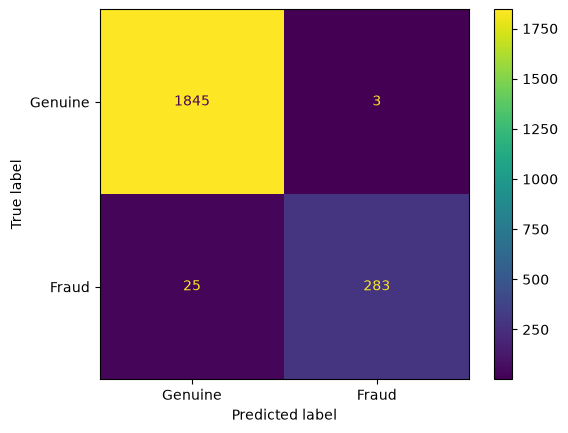

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6))
cm.plot()

In [23]:
from xgboost import XGBClassifier

# Calculate scale pos weight for imbalance in xgboost classifier
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Create XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Build the complete pipeline
pipeline_xgb = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb_model)
    ]
)

# Train the pipeline (using raw X_train, not processed)
pipeline_xgb.fit(X_train, y_train)


# Make predictions
y_pred_xgb = pipeline_xgb.predict(X_test)
y_proba_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

c:\Users\User\Downloads\Fraudulent-Transaction_Detection_For_FinLora_Company\finLora_env\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 6, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\User\Downloads\Fraudulent-Transaction_Detection_For_FinLora_Company\finLora_env\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 6, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


XGBoost Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      1848
       Fraud       0.96      0.92      0.94       308

    accuracy                           0.98      2156
   macro avg       0.97      0.96      0.96      2156
weighted avg       0.98      0.98      0.98      2156


Confusion Matrix:
[[1835   13]
 [  25  283]]

ROC_AUC Score: 0.9747


Confusion Matrix For XGBoost

<Figure size 800x600 with 0 Axes>

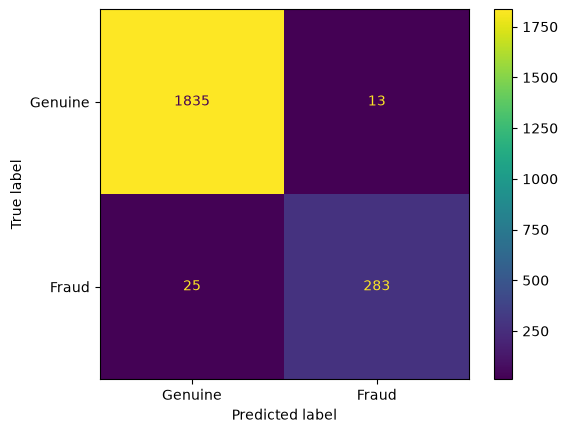

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6))
cm.plot()

SHAP ANALYSIS  

SHAP is a technique used to explain machine learning predictions — especially complex models like tree ensembles — in a way that shows how each feature contributes to a decision.  SHAP answers this question: "Why did the model say this transaction is fraud?"  It does this by assigning each feature a contribution value (positive or negative) to the prediction. SHAP is used to interpret model predictions by quantifying the contribution of each feature to fraud risk. This enables transparency in decision-making, helped identify key fraud drivers such as transaction velocity and IP risk score, and provided actionable insights for fraud analysts and business stakeholders.  SHAP is based on Game Theory, specifically Shapley values. It fairly distributes the "credit" of a prediction across features.

In [28]:
!pip install shap
import shap
import xgboost

print("SHAP version:", shap.__version__)
print("XGBoost version:", xgboost.__version__)

   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
    --------------------------------------- 0.8/43.0 MB 3.1 MB/s eta 0:00:14
   - -------------------------------------- 2.1/43.0 MB 5.0 MB/s eta 0:00:09
   - -------------------------------------- 2.1/43.0 MB 5.0 MB/s eta 0:00:09
   - -------------------------------------- 2.1/43.0 MB 5.0 MB/s eta 0:00:09
   - -------------------------------------- 2.1/43.0 MB 5.0 MB/s eta 0:00:09
   - -------------------------------------- 2.1/43.0 MB 5.0 MB/s eta 0:00:09
   - -------------------------------------- 2.1/43.0 MB 5.0 MB/s eta 0:00:09
   - -------------------------------------- 2.1/43.0 MB 5.0 MB/s eta 0:00:09
   - -------------------------------------- 2.1/43.0 MB 5.0 MB/s eta 0:00:09
   - -------------------------------------- 2.1/43.0 MB 5.0 MB/s eta 0:00:09
   - -------------------------------------- 2.1/43.0 MB 5.0 MB/s eta 0:00:09
   - -------------------------------------- 2.1/43.0 MB 5.0 MB/s eta 0:00:09
   - -

c:\Users\User\Downloads\Fraudulent-Transaction_Detection_For_FinLora_Company\finLora_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0
XGBoost version: 3.4.1


In [29]:
import shap
import xgboost

print("SHAP version:", shap.__version__)
print("XGBoost version:", xgboost.__version__)

SHAP version: 0.52.0
XGBoost version: 3.4.1


In [30]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Get the preprocessor from pipeline and transform raw X_test
X_test_processed = pipeline_xgb.named_steps['preprocessor'].transform(X_test)

# Get the XGBoost model from pipeline
xgb_model = pipeline_xgb.named_steps['classifier']

# Get booster and calculate SHAP values
booster = xgb_model.get_booster()
explainer = shap.TreeExplainer(booster)
shap_values_gb = explainer.shap_values(X_test_processed)

c:\Users\User\Downloads\Fraudulent-Transaction_Detection_For_FinLora_Company\finLora_env\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 6, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


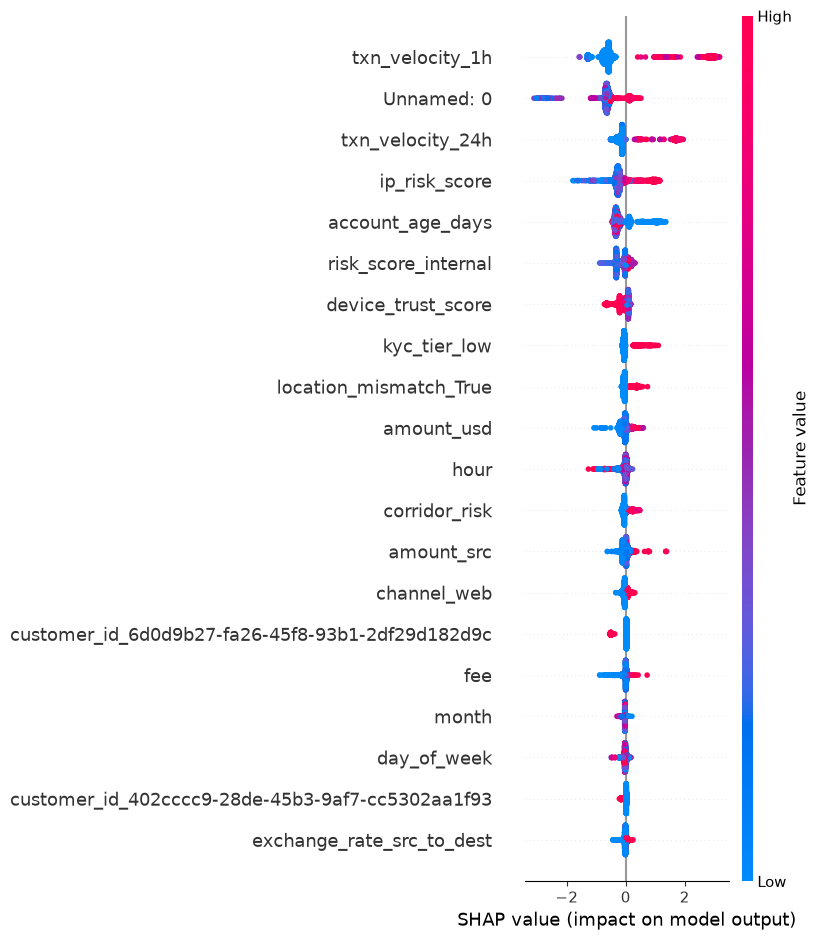

In [31]:
# Creating a clean feature name for the shap plot
feature_names = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()
clean_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=clean_names
)

# Beeswarm plot
shap.summary_plot(shap_values_gb, X_test_processed_df)
plt.show()

This is a SHAP beeswarm plot, and it shows which features matter most and how they influence fraud predictions. The Y-axis shows the features (ranked by importance) while the X-axis shows the SHAP value (impact on prediction). The Blue color represents Low feature value while the red color represents High feature value.  The Left part of the plot (negative SHAP value) pushes prediction toward Genuine while the Right part (positive SHAP value) pushes prediction toward Fraud.  The SHAP beeswarm plot highlights that transaction velocity spikes, location mismatch, internal risk scores, and IP risk scores are the most influential drivers of fraud predictions. High values of these features consistently push predictions toward fraud, while low values indicate genuine behaviour. The model captures a combination of behavioural anomalies, identity inconsistencies, and account risk factors, aligning closely with real-world fraud detection patterns.

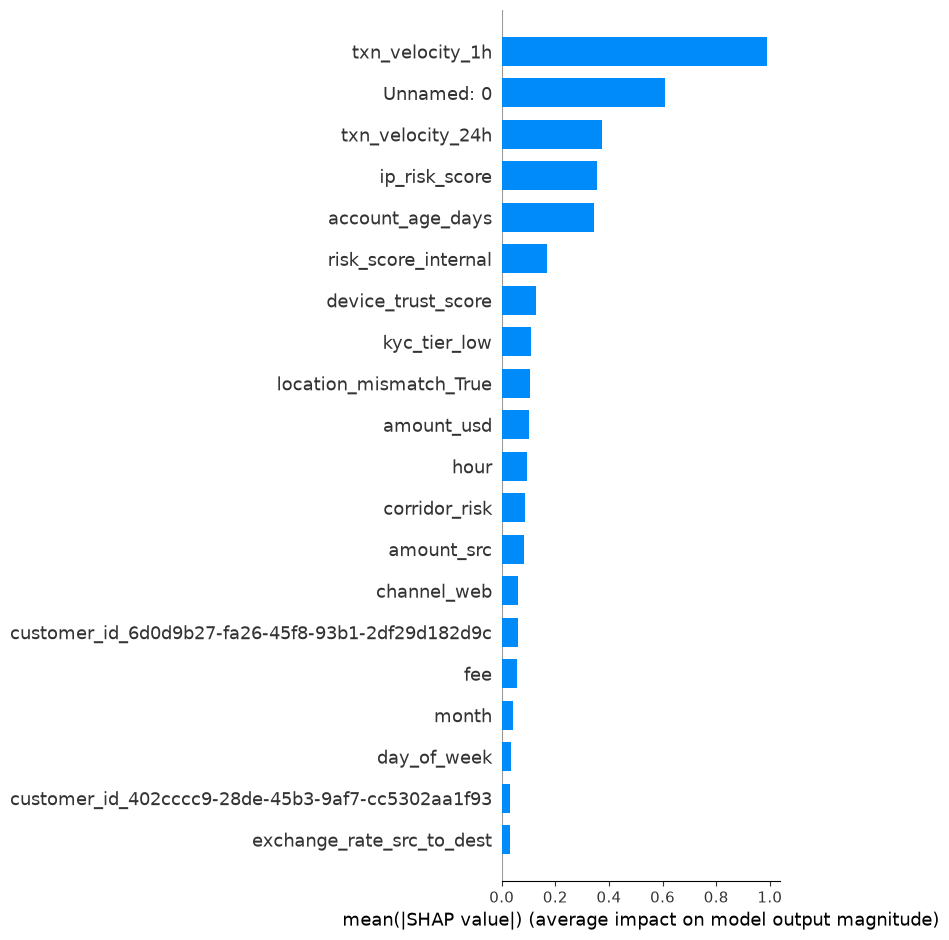

In [32]:
# Summary bar plot
shap.summary_plot(shap_values_gb, X_test_processed_df, plot_type="bar")
plt.show()

Model registering

In [36]:
import dagshub
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize DagsHub
import dagshub
import dagshub
dagshub.init(repo_owner='prinxlordstone', 
            repo_name='Fraudulent-Transaction_Detection_For_FinLora_Company', 
            mlflow=True)


Initialized MLflow to track repo "prinxlordstone/Fraudulent-Transaction_Detection_For_FinLora_Company"

Repository prinxlordstone/Fraudulent-Transaction_Detection_For_FinLora_Company initialized!

In [37]:
# Set experiment
mlflow.set_experiment("Fraudulent_transaction_Detection_Models_For_Finlora")

# Start MLflow run and register model
with mlflow.start_run() as run:
    # Log model parameters
    mlflow.log_params(xgb_model.get_params())
    
    # Make predictions using the pipeline
    y_pred = pipeline_xgb.predict(X_test)
    y_pred_proba = pipeline_xgb.predict_proba(X_test)[:, 1]

    # Log metrics
    mlflow.log_metrics({
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'auc_roc': roc_auc_score(y_test, y_pred_proba)
    })

    # Log the entire pipeline (preprocessor + model) with cloudpickle serialization
    mlflow.sklearn.log_model(
    pipeline_xgb,
    "xgboost_fraud_detection_pipeline",
    registered_model_name="Fraud_Detection_XGBoost_Pipeline",
    serialization_format='cloudpickle'
    )

    print(f"Model registered successfully!")
    print(f"Run ID: {run.info.run_id}")

2026/09/22 23:44:54 INFO mlflow.tracking.fluent: Experiment with name 'Fraudulent_transaction_Detection_Models_For_Finlora' does not exist. Creating a new experiment.
c:\Users\User\Downloads\Fraudulent-Transaction_Detection_For_FinLora_Company\finLora_env\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 6, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\User\Downloads\Fraudulent-Transaction_Detection_For_FinLora_Company\finLora_env\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 6, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
2026/09/22 23:45:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/22 23:45:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpic

Model registered successfully!
Run ID: dd4966c021c1418a82af3533af76647f
🏃 View run bedecked-steed-14 at: https://dagshub.com/prinxlordstone/Fraudulent-Transaction_Detection_For_FinLora_Company.mlflow/#/experiments/0/runs/dd4966c021c1418a82af3533af76647f
🧪 View experiment at: https://dagshub.com/prinxlordstone/Fraudulent-Transaction_Detection_For_FinLora_Company.mlflow/#/experiments/0


In [ ]:
# Building preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# Fit on train, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original features: {len(all_features)}")
print(f"Processed features: {X_train_processed.shape[1]}")

c:\Users\User\Downloads\Fraudulent-Transaction_Detection_For_FinLora_Company\finLora_env\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 6, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Original features: 33
Processed features: 19548
